<a href="https://colab.research.google.com/github/Migue0110/API/blob/main/ACA2_G3_Programaci%C3%B3n_para_anal%C3%ADtica_de_datos_e_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**ACA 1 – Programación para Analítica de Datos e IA**

---
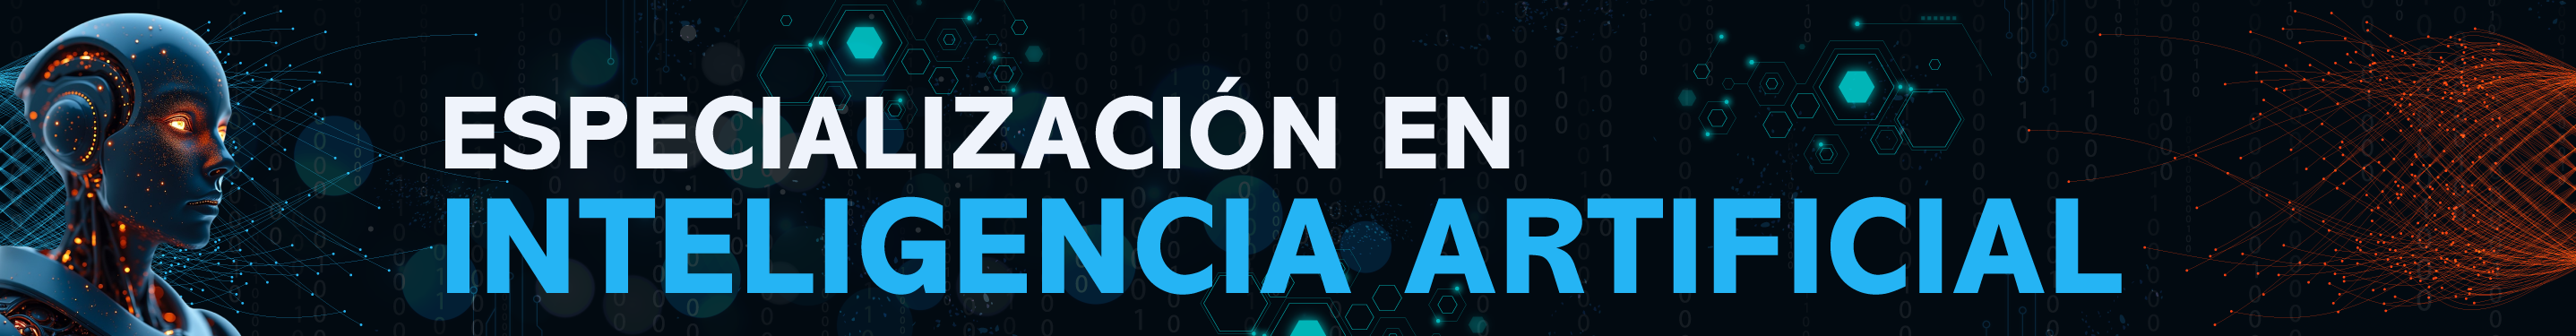

##**Integrantes**

>- Johnny Alirio Blanquicett Cardona.
>- Miguel Orlando Mora Moreno.
>- Ramón Benjamín Buelvas Sierra.
>- Rubby Yesenia Parrado Rodríguez.

---

## **Informe Técnico Avanzado**
###**Análisis dataset Titanic**

>- **Autor:** Grupo3

>- **Herramientas:** Python 3, Pandas, NumPy, Matplotlib, Seaborn.

>- **Descripción del dataset:** Contiene información de pasajeros del Titanic. Permite analizar factores relacionados con la supervivencia durante el accidente, como edad, sexo, clase del tiquete y tarifa pagada.

>- **Objetivo del ejercicio:** Analizar exploratoriamente el dataset Titanic para identificar patrones y asociaciones entre las características demográficas (sexo), socioeconómicas (clase) y familiares de los pasajeros (solo o acompañado) y su incidencia sobre la tasa de supervivencia, mediante procesos de preparación, transformación, visualización e interpretación de datos.

>- **Variables estudiadas:** Survived como variable principal de resultado; Sex para analizar diferencias por sexo; Pclass como aproximación a la condición socioeconómica; Age para considerar la edad; Embarked para identificar el puerto de embarque; Cabin, transformada en Deck, para aproximar la ubicación del pasajero; SibSp y Parch como variables familiares; y las variables derivadas FamilySize e IsAlone, utilizadas para estudiar el tamaño del grupo familiar y la condición de viajar solo o acompañado.
---

**Importación de librerías**

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

**Conectar a Google Drive**

In [79]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


**Cargar dataset**

In [80]:
df = pd.read_csv('/content/drive/MyDrive/programacion/ACA1/titanic.csv')
df_training = pd.read_csv('/content/drive/MyDrive/programacion/ACA1/titanic.csv')

**Cantidad de filas y columnas que posee:**

In [81]:
df.shape

(891, 12)

**Visualizar dataset**

In [82]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **Número de columnas, cantidad y tipo de datos**

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Valores faltantes**

In [84]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


**Análisis de variable objetivo**

In [85]:
print("Valores de variable objetivo \n")
print(df['Survived'].value_counts())
print("\nPorcentaje de supervivencia:\n")
print(df['Survived'].value_counts(normalize=True).mul(100).round(1))

Valores de variable objetivo 

Survived
0    549
1    342
Name: count, dtype: int64

Porcentaje de supervivencia:

Survived
0    61.6
1    38.4
Name: proportion, dtype: float64


**Análisis inicial del DataFrame**


---


>La exploración inicial permitió reconocer la estructura del conjunto de
datos, los tipos de variables y la presencia de valores faltantes. El
dataset integra características demográficas, socioeconómicas y
familiares de los pasajeros, junto con la variable `Survived`, utilizada
para distinguir entre sobrevivientes y no sobrevivientes.

**Limpieza de datos**

---

La revisión mediante `shape`, `head()`, `info()` y el conteo de valores
nulos permitió establecer las necesidades de preparación antes de
realizar comparaciones. La presencia de datos faltantes en variables
como edad, puerto de embarque y cabina justificó tratamientos
diferenciados según la naturaleza de cada variable.


**Extracción del título del nombre**

**Objetivo:** Realizar la extracción del título del nombre *Mr, Mrs, Miss, Master, Don, Rev, Dr, Mme, Ms, Major, Lady, Sir, Mlle, Col, Capt, Countess, Jonkheer* con el objetivo de identificar el título de tratamiento extraído del nombre del pasajero.

In [86]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

In [87]:
unicos = df['Title'].value_counts()
print(unicos)

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


**Rellenar las edades que posen valores NaN o valores vacíos**

**Objetivo:** Establecer un criterio de imputación para los valores faltantes de la variable edad, utilizando como referencia la mediana de edad correspondiente a cada título de tratamiento *(Mr., Mrs., Miss, entre otros)*, con el fin de completar los registros que presentan valores nulos y mantener la consistencia de los datos para el análisis posterior.

**Nota:** La edad imputada constituye una estimación y no una observación original. Los resultados relacionados con esta variable deben interpretarse considerando dicha limitación.


In [88]:
df['Age'] = df.groupby('Title')['Age'].transform(
    lambda x: x.fillna(x.median())
)

**Rellenar la columna Embarked que posee valores NaN o valores vacíos**

**Objetivo:** Determinar la categoría con mayor frecuencia (moda) en la variable Embarked, para utilizar como criterio de imputación con el fin de completar los registros que posean valores faltantes o nulos.

In [89]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

**Rellenar la columna Deck que poseen valores NaN o valores vacíos**

**Objetivo:** Extraer la letra de la columna (Cabin) en la columna (Deck) para Simplificar cabinas específicas en 8 niveles generales y agrupar los datos faltantes como 'Unknown', permitiendo analizar la relación entre la ubicación física del pasajero y su supervivencia.

In [90]:
df['Deck'] = df['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else 'Unknown')

**Validar si el pasajero viajaba solo o acompañado**

**Objetivo:** Consolidar el total de familiares a bordo (FamilySize) y crear un indicador binario (IsAlone) para evaluar el impacto del acompañamiento familiar en la tasa de supervivencia.

In [91]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [92]:
df.drop(columns=['Cabin'])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,Deck,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr,Unknown,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss,Unknown,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs,C,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr,Unknown,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,Rev,Unknown,1,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,Miss,B,1,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.0,1,2,W./C. 6607,23.4500,S,Miss,Unknown,4,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,Mr,C,1,1


La preparación incorporó variables derivadas para ampliar las
posibilidades del análisis exploratorio. `Deck` simplifica la
información de `Cabin` mediante la identificación de la cubierta y
conserva los registros sin cabina conocida bajo `Unknown`. Esta
categoría representa ausencia de información y no una ubicación física
dentro del barco por lo que se simplifica la información en `Deck` y se elimina la columna `Cabin`.

`FamilySize` integra las variables familiares originales para
representar el número de personas del núcleo familiar registradas junto
con cada pasajero, incluido el propio individuo. Posteriormente,
`IsAlone` diferencia a quienes viajaban solos de quienes registraban
acompañamiento familiar.

Las transformaciones convierten información dispersa del dataset
original en variables directamente utilizables para estudiar
asociaciones entre características familiares, ubicación y
supervivencia.

**Visualización de los datos del dataset**

**Objetivo:** Representar gráficamente las relaciones clave entre las variables demográficas, socioeconómicas y familiares frente a la tasa de supervivencia, evidenciando patrones e interacciones de los datos.

El análisis exploratorio utiliza la tasa de supervivencia como indicador
principal y examina su comportamiento frente a características
seleccionadas de los pasajeros. La primera comparación integra sexo y
clase del tiquete; la segunda examina la condición de viajar solo o
acompañado.

La combinación entre sexo y clase incorpora simultáneamente una
característica demográfica y una característica socioeconómica. La
condición de viaje incorpora una dimensión familiar construida a partir
de las variables originales.

Las tasas porcentuales facilitan la comparación entre grupos de
diferente tamaño. La lectura de las visualizaciones se concentra, por
tanto, en la proporción de sobrevivientes dentro de cada categoría.

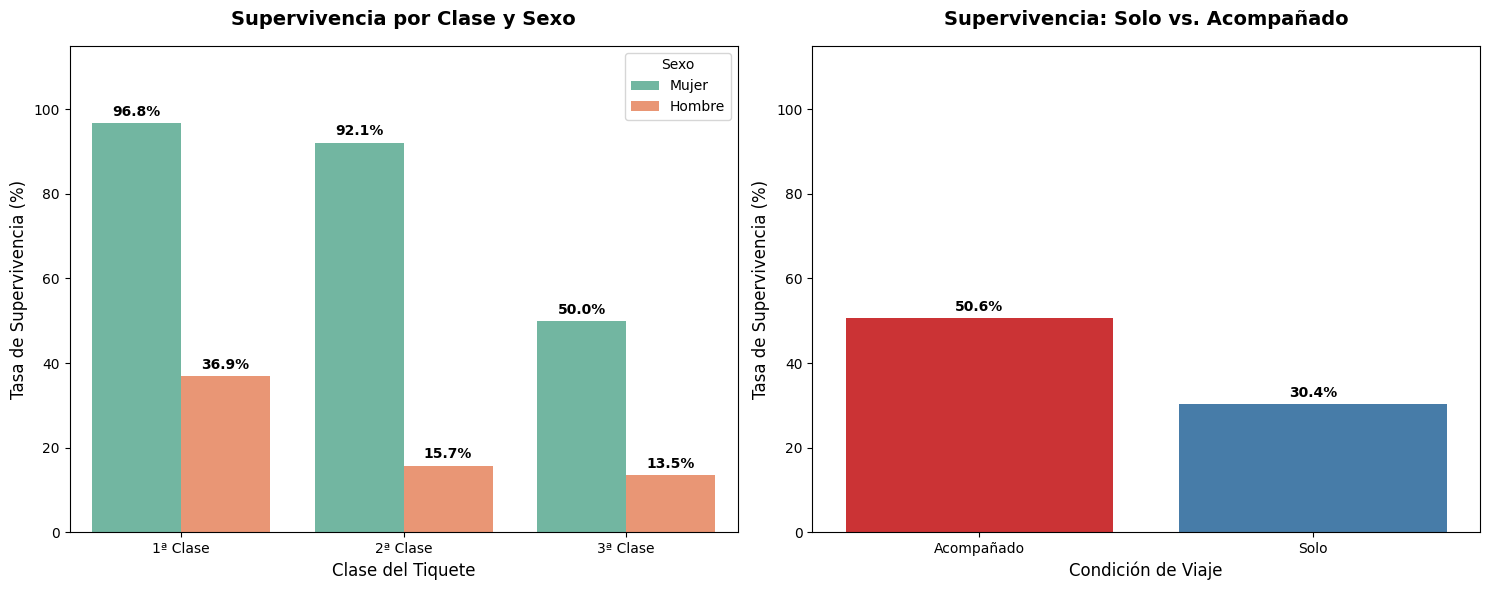

In [93]:
# Multiplicar por 100 para visualizar la tasa como porcentaje directo
df['SurvivedPct'] = df['Survived'] * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Gráfica 1: Clase y Sexo ---
sns.barplot(
    data=df,
    x='Pclass',
    y='SurvivedPct',
    hue='Sex',
    ax=axes[0],
    errorbar=None,
    palette='Set2',
)
axes[0].set_title(
    'Supervivencia por Clase y Sexo', fontsize=14, fontweight='bold', pad=15
)
axes[0].set_xlabel('Clase del Tiquete', fontsize=12)
axes[0].set_ylabel('Tasa de Supervivencia (%)', fontsize=12)
axes[0].set_xticklabels(['1ª Clase', '2ª Clase', '3ª Clase'])
axes[0].set_ylim(0, 115)
axes[0].legend(title='Sexo', labels=[ 'Mujer', 'Hombre'])

# Agregar el valor porcentual exacto sobre cada barra
for container in axes[0].containers:
  axes[0].bar_label(
      container, fmt='%.1f%%', padding=3, fontsize=10, fontweight='bold'
  )

# --- Gráfica 2: Acompañado vs Solo ---
sns.barplot(
    data=df,
    x='IsAlone',
    y='SurvivedPct',
    ax=axes[1],
    errorbar=None,
    palette='Set1',
)
axes[1].set_title(
    'Supervivencia: Solo vs. Acompañado', fontsize=14, fontweight='bold', pad=15
)
axes[1].set_xlabel('Condición de Viaje', fontsize=12)
axes[1].set_ylabel('Tasa de Supervivencia (%)', fontsize=12)
axes[1].set_xticklabels(['Acompañado', 'Solo'])
axes[1].set_ylim(0, 115)

# Agregar el valor porcentual exacto sobre cada barra
for container in axes[1].containers:
  axes[1].bar_label(
      container, fmt='%.1f%%', padding=3, fontsize=10, fontweight='bold'
  )

plt.tight_layout()
plt.show()

>**Gráfico 1**

---

>La comparación conjunta entre sexo, clase del tiquete y supervivencia
muestra diferencias marcadas entre los grupos analizados. Las mujeres
presentan tasas de supervivencia superiores al 50 % en las tres clases,
con valores de 96,8 % en primera clase y 92,1 % en segunda clase. Los
hombres presentan tasas inferiores, y los hombres de tercera clase
registran una supervivencia de 13,5 %.

>Los resultados muestran una asociación entre sexo, clase del tiquete y
supervivencia. La comparación también evidencia que una tasa global
ocultaría diferencias relevantes entre los grupos de pasajeros.

>Las relaciones observadas tienen carácter descriptivo. El análisis
realizado no permite atribuir las diferencias directamente a una causa
específica ni demostrar por sí mismo el efecto de un protocolo de
evacuación.



>**Gráfico 2**

---

>Los pasajeros acompañados registran una tasa de supervivencia de 50,6 %,
mientras que quienes viajaban solos presentan una tasa de 30,4 %. La
diferencia entre ambos grupos alcanza **20,2 puntos porcentuales**.

>Los resultados muestran una asociación entre acompañamiento familiar y
supervivencia dentro de la muestra. La variable `IsAlone` permite
identificar un patrón que no aparece directamente en las columnas
originales, lo que evidencia la utilidad analítica de construir
variables derivadas durante la preparación.

>La diferencia observada no demuestra una relación causal. Variables como
sexo y clase del tiquete también presentan diferencias de supervivencia
y pueden relacionarse con la composición de los grupos comparados.

**Conclusiones del Análisis**

>1. El análisis evidencia una asociación entre sexo, clase del
tiquete y supervivencia. Las mujeres registraron mayores tasas de
supervivencia en las tres clases, alcanzando 96,8 % en primera clase y
92,1 % en segunda, mientras que los hombres de tercera clase presentaron
una tasa de 13,5 %.

>2. Los pasajeros acompañados registraron una tasa de supervivencia
de 50,6 %, frente al 30,4 % de quienes viajaban solos, lo que evidencia
una asociación entre la condición de acompañamiento y la supervivencia
dentro del conjunto de datos analizado.


**Conclusiones del desarrollo**

>1.   La imputación contextual de edades por título de tratamiento y el
> manejo de cabinas faltantes bajo la categoría `Unknown` permitieron
> conservar la totalidad de los registros y evitar la eliminación de
> observaciones debido a valores faltantes.

>2.   La creación de variables derivadas como FamilySize e IsAlone aportó profundidad al análisis exploratorio al descubrir patrones de comportamiento social que no eran evidentes en los datos primarios.

>3.   La inclusión de etiquetas porcentuales sobre las barras y la documentación en Markdown estructuraron el cuaderno de Google Colab como un informe técnico reproducible y de fácil lectura.

**Anexo 1: Programación realizada con Google Colab**

Para ver el trabajo en Google Colab pueden ingresar como comentador con correo CUN
Link: https://colab.research.google.com/drive/11riN28-hbGkiN47iKdGwjTd7InoF3D7c?usp=sharing

#**ACA 2 - Entrenamiento Machine Learning - Titanic**
---

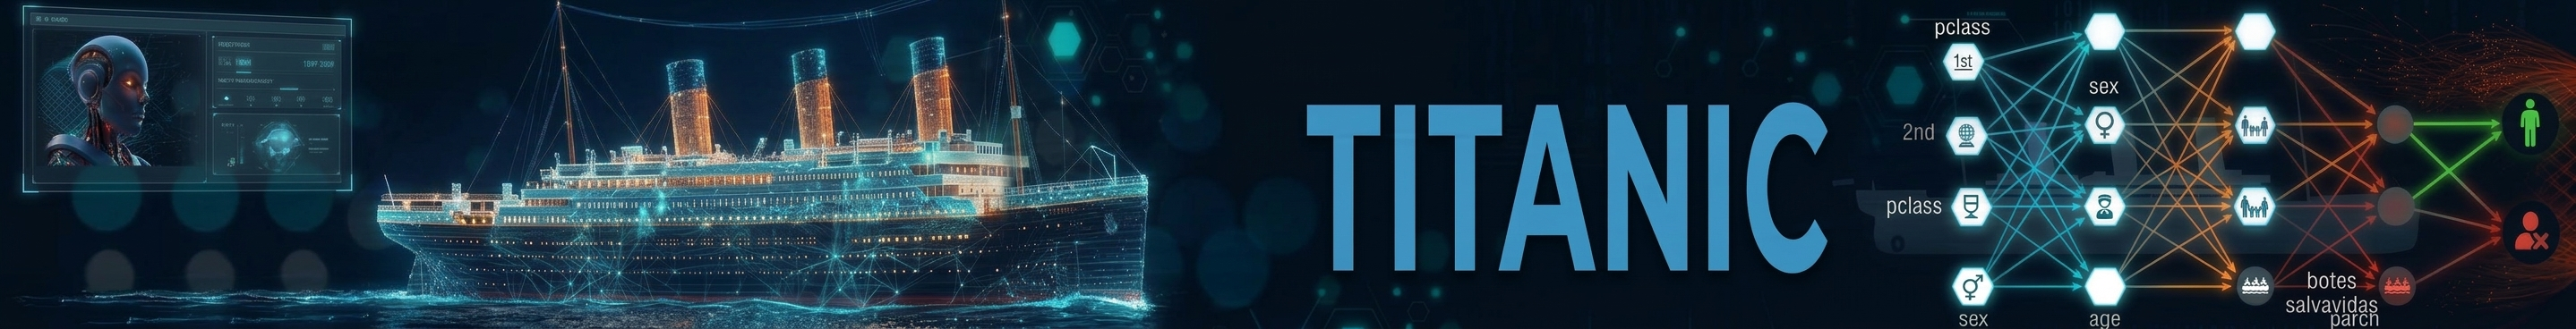

>**1. Informe técnico del entrenamiento de modelos**

---

> **Dataset:** Titanic.  
**Variable objetivo:** Survived.  
**Tipo de problema:** Clasificación supervisada.  
**Modelos a entrenar:** LogisticRegression, KNeighborsClassifier, RandomForestClassifier.

>**2. Contexto y planteamiento del problema**

---

> El conjunto de datos `Titanic` contiene información de pasajeros como
sexo, edad, clase del pasajero, tarifa pagada y características
relacionadas con su grupo familiar.

>Se pretende predecir la supervivencia de pasajeros del titanic con base al analisis previo realizado en el ACA1

>La variable `Survived` representa el resultado que se desea predecir:
> - 0: No sobrevivió
> - 1: Sobrevivió

>Debido a que la variable objetivo representa dos categorías, se interpreta que el problema corresponde a una tarea de clasificación binaria.

>**3. Importación de librerias necesarias.**

---

>

In [94]:
# Libreria necesaria para apoyo de operaciones numéricas.
import numpy as np

>Librería utilizada para realizar operaciones numéricas y trabajar con arreglos de datos.

---



In [95]:
# Libreria para separar datos en entrenamiento y prueba.
from sklearn.model_selection import train_test_split

>Esta libreria nos permite dividir los datos en dos grupos: entrenamiento y prueba.

>**Entrenamiento:** Datos que utiliza el modelo para aprender.  
>**Prueba:** Datos que utiliza para comprobar qué tan bien aprendió.

---

In [96]:
## Libreria para validación cruzada manteniendo la misma proporción de clases.
from sklearn.model_selection import StratifiedKFold

>Permite realizar validación cruzada, dividiendo los datos en varias partes y manteniendo aproximadamente la misma proporción de clases en cada grupo.


---

In [97]:
# Libreria para comparar los modelos utilizando validación cruzada.
from sklearn.model_selection import cross_validate

>Permite evaluar un modelo mediante validación cruzada y obtener diferentes métricas de rendimiento.

>Esto facilita comparar cómo funciona un modelo en diferentes divisiones de los datos.

---

In [98]:
# Libreria para aplicar transformaciones a distintas columnas.
from sklearn.compose import ColumnTransformer

>Permite aplicar diferentes transformaciones a diferentes columnas del conjunto de datos.

>**Ejemplo:** podemos estandarizar las columnas numéricas y convertir las columnas de texto a números.

---



In [99]:
# Libreria para mitigar el data leakage (pipeline).
from sklearn.pipeline import Pipeline

>Permite organizar varias etapas del procesamiento y entrenamiento en un solo flujo.

>También ayuda a evitar el data leakage _(fuga de información)_, evitando que información de los datos de prueba sea utilizada accidentalmente durante el entrenamiento.

---

In [100]:
# Libreria para completar valores faltantes.
from sklearn.impute import SimpleImputer

>Permite completar los valores faltantes de los datos.

>**Ejemplo:** si una columna tiene valores vacíos, podemos reemplazarlos por la media, mediana o un valor determinado.

---

In [101]:
# Libreria para convertir categorias en variables numéricas.
from sklearn.preprocessing import OneHotEncoder

>Convierte categorías de texto en valores numéricos que el modelo pueda interpretar.

>**Ejemplo:** Sexo = Masculino / Femenino

>Se puede convertir en columnas como:
Sexo_Masculino y Sexo_Femenino  
Teniendo estas valores numericos booleanos (1 verdadero - 0 falso)

---

In [102]:
# Libreria para estandarizar variables numéricas.
from sklearn.preprocessing import StandardScaler

>Estandariza las variables numéricas para que tengan una escala comparable.

>Esto es especialmente útil para modelos sensibles a las diferencias de escala, como KNN y Regresión Logística.

---



In [103]:
# Importación de modelos de entrenamiento.
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

>**LogisticRegression:**  utilizado principalmente para clasificación.  
Permite predecir a qué clase pertenece un registro, por ejemplo: sobrevive o no sobrevive.

>**KNeighborsClassifier:** Clasifica un dato observando los datos más cercanos a él.  
La idea básica es: si la mayoría de sus vecinos pertenecen a una clase, probablemente el nuevo dato también pertenezca a esa clase.    

>**RandomForestClassifier:** Modelo que combina varios árboles de decisión para realizar una clasificación.  
Al combinar muchos árboles, busca obtener predicciones más estables y precisas.

---



---



In [104]:
# Metricas necesarias para la evaluación de los modelos.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

>**accuracy_score:** Indica el porcentaje total de predicciones correctas realizadas por el modelo.

>**precision_score:** Indica qué tan precisas son las predicciones positivas del modelo.

>**recall_score:** Indica qué tan bien el modelo encuentra los casos que realmente pertenecen a la clase positiva.

>**f1_score:** Combina precision y recall en una sola métrica. Es útil cuando queremos evaluar ambas características al mismo tiempo, especialmente cuando las clases no están equilibradas.

>**roc_auc_score:** Mide qué tan bien el modelo puede diferenciar entre las clases. Un valor más cercano a 1 indica una mejor capacidad de separación entre las clases.

>**confusion_matrix:** Muestra en una tabla cuántas predicciones fueron correctas y cuántas fueron incorrectas para cada clase.  
Permite identificar casos como:
>- Verdaderos positivos.
>- Verdaderos negativos.
>- Falsos positivos.
>- Falsos negativos.

>**classification_report:** Genera un resumen de las principales métricas de clasificación para cada clase.

>**RocCurveDisplay:** Permite visualizar la curva ROC _(Receiver Operating Characteristic)_ del modelo. Sirve para observar gráficamente qué tan bien el modelo diferencia entre las diferentes clases.  

>**4. Uso del dataset**

---

> Se utilizará el mismo conjunto de datos Titanic trabajado durante el ACA 1, para evitar dañar el analisis previo, se optó por duplicar el dataframe en la variable: `df_training` la cual será usada durante el proceso de inspección, auditoria y entrenamiento, con base en la retroalimentación dada en el ACA 1.

>**5. Primera inspección**

---

In [105]:
# Número de fias y columnas.

print("El data Frame posee un total de Filas y columnas:")
df_training.shape

El data Frame posee un total de Filas y columnas:


(891, 12)

In [106]:
# Información del dataframe.

print("Información general:\n")
df_training.info()

Información general:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [107]:
# Contenido del dataframe.

print("Primeras 5 filas del dataframe:\n")
display(df_training.head())

Primeras 5 filas del dataframe:



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


>**6. Auditoría de calidad**


---

In [108]:
print("Valores faltantes por columna:\n")
display(df_training.isnull().sum())

Valores faltantes por columna:



,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [109]:
print("Cantidad de duplicados:\n")
print(df_training.duplicated().sum())

Cantidad de duplicados:

0


In [110]:
print("Valores únicos por columna:\n")
display(df_training.nunique())

Valores únicos por columna:



,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


In [111]:
print("Estadísticas numéricas:\n")
display(df_training.describe())

Estadísticas numéricas:



,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


>**7. Porcentaje de valores faltantes**

In [112]:
missing = df_training.isnull().sum()

missing_pct = (missing / len(df_training)) * 100

missing_table = pd.DataFrame({
    'Valores faltantes': missing,
    'Porcentaje (%)': missing_pct.round(2)
})

display(missing_table)

,Valores faltantes,Porcentaje (%)
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Ticket,0,0.00
Fare,0,0.00


>**8. validación de inconsistencias**

In [113]:
print("Valores de Survived:")
print(df_training['Survived'].unique())

print("\nValores de Pclass:")
print(df_training['Pclass'].unique())

print("\nValores de Sex:")
print(df_training['Sex'].unique())

print("\nValores de Embarked:")
print(df_training['Embarked'].unique())

print("\nRango de Age:")
print(df_training['Age'].min(), "a", df['Age'].max())

print("\nRango de Fare:")
print(df_training['Fare'].min(), "a", df['Fare'].max())

Valores de Survived:
[0 1]

Valores de Pclass:
[3 1 2]

Valores de Sex:
['male' 'female']

Valores de Embarked:
['S' 'C' 'Q' nan]

Rango de Age:
0.42 a 80.0

Rango de Fare:
0.0 a 512.3292


>**9. Distribución del target**

---

Antes de realizar el entrenamiento de los modelos, se realizará el analisis correspondiente a la distribución de las clases, con el fin de determinar si existe algun desbalance a considerar durante la evaluación.

In [114]:
target_counts = df_training['Survived'].value_counts().sort_index()

target_pct = df_training['Survived'].value_counts(normalize=True).sort_index() * 100

target_table = pd.DataFrame({
    'Cantidad': target_counts,
    'Porcentaje (%)': target_pct.round(2)
})

display(target_table)

,Cantidad,Porcentaje (%)
Survived,,
0,549,61.62
1,342,38.38


**Análisis del Desbalance de Clases:**

La variable objetivo presenta un desbalance moderado, donde la clase mayoritaria `(No sobrevive, 0)` representa el 61.6% y la clase minoritaria `(Sobrevive, 1)` el 38.4%. Debido a que la clase minoritaria cuenta con una representación suficiente, no se considera necesario aplicar técnicas de generación de datos sintéticos como SMOTE, ya que podrían introducir ruido o alterar las relaciones originales de los datos. Por esta razón, el desbalance se manejará mediante un muestreo estratificado `(stratify=y)` durante la división de los datos y utilizando métricas como el F1-score y el área bajo la curva ROC (AUC) para evaluar el desempeño del modelo.

>**10. Visualización del desbalance del target**

---

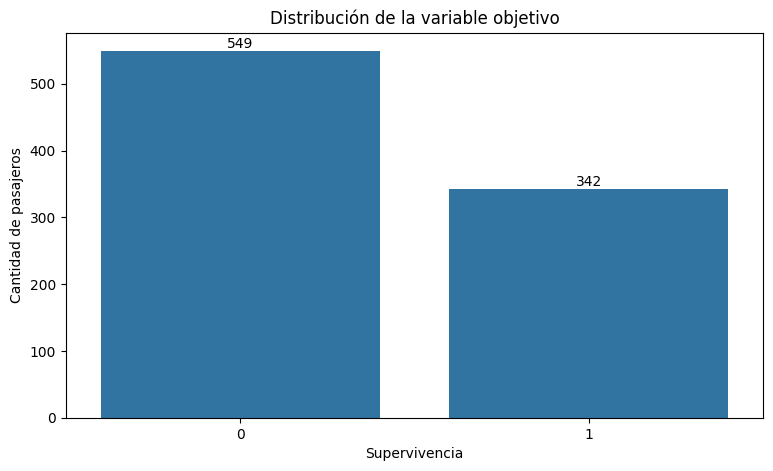

In [115]:
plt.figure(figsize=(9, 5))

ax = sns.countplot(data=df_training, x='Survived')

plt.title('Distribución de la variable objetivo')
plt.xlabel('Supervivencia')
plt.ylabel('Cantidad de pasajeros')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

El gráfico muestra la distribución de la variable objetivo `Survived` en el conjunto de datos del Titanic.

Se observan dos categorías:

- **0 - (No sobrevivió):** 549 pasajeros.
- **1 - (Sobrevivió):** 342 pasajeros.

El conjunto de datos contiene un total de **891 pasajeros**. Por lo tanto, aproximadamente el **61,6 %** de los pasajeros no sobrevivió, mientras que el **38,4 %** sobrevivió.

>**11. Análisis de la variable Age**

---

La variable `Age` presenta valores faltantes, por lo que primero se
analiza su distribución antes de definir la estrategia de imputación.

In [116]:
display(df_training['Age'].describe())

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


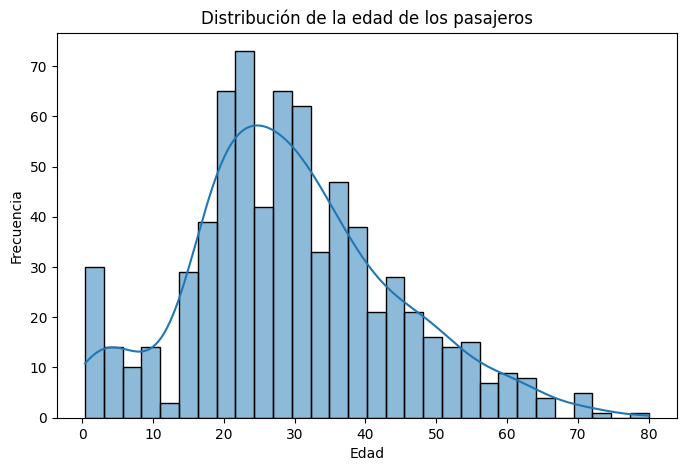

In [117]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df_training, x='Age', bins=30, kde=True)

plt.title('Distribución de la edad de los pasajeros')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

Se presenta una distribución de edades asimétrica positiva (sesgada hacia la derecha), caracterizada por un amplio predominio de adultos jóvenes y un grupo representativo de niños. Se aprecia que La mayor parte de la población a bordo se concentraba entre los 18 y 35 años, alcanzando su punto máximo de frecuencia entre los 20 y 25 años.  

A partir de los 40 años la cantidad de pasajeros disminuye de manera constante. La presencia de adultos mayores de 60 años es muy reducida, alcanzando un límite superior cercano a los 80 años.

>**12. Variable Age vs variable Survived**

---

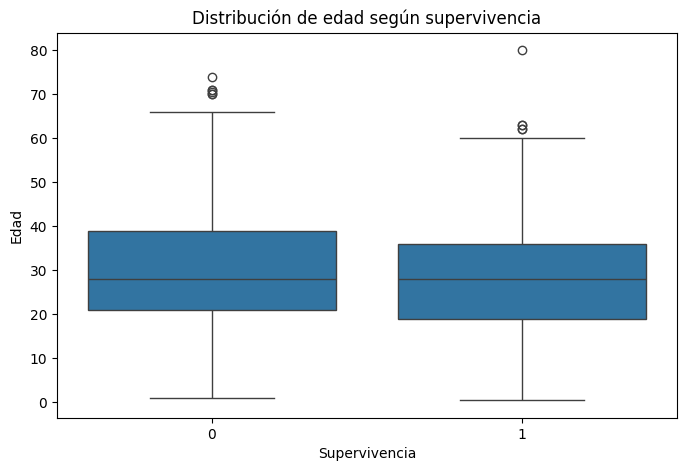

In [118]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_training, x='Survived', y='Age')

plt.title('Distribución de edad según supervivencia')
plt.xlabel('Supervivencia')
plt.ylabel('Edad')

plt.show()

El gráfico permite observar diferencias en la distribución de edad entre los pasajeros que sobrevivieron y quienes no sobrevivieron.

**Hallazgos:**  

- Tanto los sobrevivientes (1) como los no sobrevivientes (0) comparten una mediana cercana a los 28 años.
- En el grupo de fallecidos hay varios puntos atípicos sobre los 70 años, mientras que en los sobrevivientes destaca un único outlier extremo de 80 años

>**13. Análisis de variable Fare**

---


In [119]:
display(df_training['Fare'].describe())

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


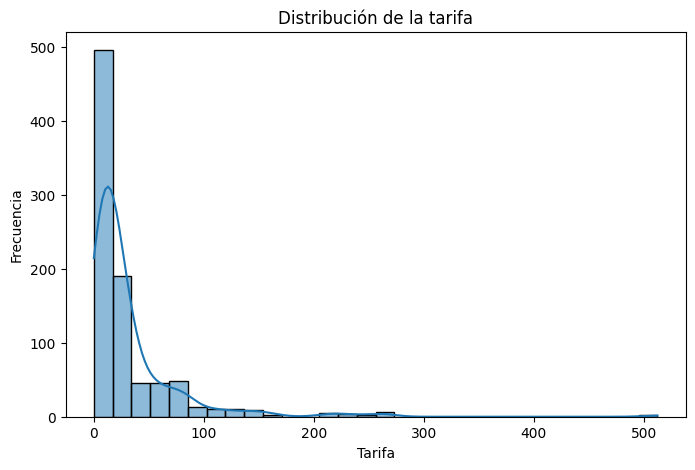

In [120]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df_training, x='Fare', bins=30, kde=True)

plt.title('Distribución de la tarifa')
plt.xlabel('Tarifa')
plt.ylabel('Frecuencia')

plt.show()

Con base en el grafico, la gran mayoría de los pasajes se agrupan en el rango de 0 a 30 (tarifas económicas de 3ª y 2ª clase).

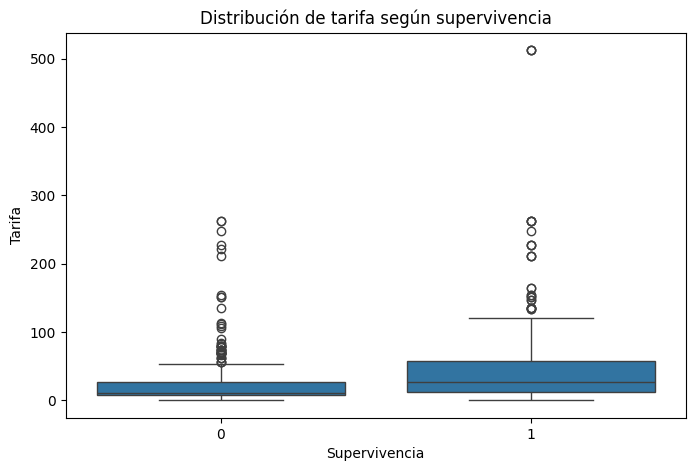

In [121]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_training, x='Survived', y='Fare')

plt.title('Distribución de tarifa según supervivencia')
plt.xlabel('Supervivencia')
plt.ylabel('Tarifa')

plt.show()

El rango intercuartílico de los sobrevivientes es más amplio y desplazado hacia valores altos, mientras que el de los no sobrevivientes se comprime fuertemente en el segmento de tarifas económicas.

>**14. Ingeniería de características**

---

A partir de las variables originales se crean algunas características
derivadas que aportan información adicional al modelo.

Se conservarán:

- `Title`: título obtenido del nombre.
- `FamilySize`: tamaño del grupo familiar.
- `IsAlone`: indicador de si el pasajero viajaba solo.
- `Deck`: cubierta obtenida a partir de `Cabin`.

Las variables identificadoras o de alta cardinalidad como `PassengerId`,
`Name` y `Ticket` no serán utilizadas directamente como predictores.

**15. Reducir títulos poco frecuentes**

---


In [122]:
df_training['Title'] = df_training['Name'].str.extract(
    r' ([A-Za-z]+)\.',
    expand=False
)

>Se tienen titulos como    

>Mr  
Miss  
Mrs  
Master  
Dr  
Rev  
Col  
...

>No se requiere demasiadas categorias para obtener un análisis preciso, por lo que las que poseen menos de 10 repeticiones para normalizar el dataframe, para esto se contarán los que aparecen menos de 10 veces y se agruparán con la categoria `Rare`

In [123]:
title_counts = df_training['Title'].value_counts()

rare_titles = title_counts[title_counts < 10].index

df_training['Title'] = df_training['Title'].replace(rare_titles, 'Rare')

df_training['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Rare,27


>**16. Family size**

---


In [124]:
df_training['FamilySize'] = (
    df_training['SibSp'] +
    df_training['Parch'] +
    1
)

>**17. Is alone**

---

In [125]:
df_training['IsAlone'] = (df_training['FamilySize'] == 1).astype(int)

0 → acompañado  
1 → viajaba solo

>**18. Deck**

---

In [126]:
df_training['Deck'] = df_training['Cabin'].str[0]

Se dejan los faltantes como categoria "Unknown"

In [127]:
df_training['Deck'] = df_training['Deck'].fillna('Unknown')

>**19. Verificar la correcta distribución de las nuevas variables**

---

In [128]:
display(
    df_training[
        [
            'Title',
            'FamilySize',
            'IsAlone',
            'Deck'
        ]
    ].head(10)
)

,Title,FamilySize,IsAlone,Deck
0,Mr,2,0,Unknown
1,Mrs,2,0,C
2,Miss,1,1,Unknown
3,Mrs,2,0,C
4,Mr,1,1,Unknown
5,Mr,1,1,Unknown
6,Mr,1,1,E
7,Master,5,0,Unknown
8,Mrs,3,0,Unknown
9,Mrs,2,0,Unknown


>**20. Definir las variables predictoras**


---  

La variable Survived se usará únicamente como variable objetivo (target).

Como predictoras, seleccionamos las siguientes características demográficas, socioeconómicas y familiares:

Pclass

Sex

Age

SibSp

Parch

Fare

Embarked

Title

Deck

FamilySize

IsAlone

Descartamos PassengerId, Name y Ticket, ya que funcionan como simples identificadores o presentan una alta cardinalidad, lo que dificulta su uso e interpretación directa en el modelo.

In [129]:
#X e Y

features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked',
    'Title',
    'Deck',
    'FamilySize',
    'IsAlone'
]

X = df_training[features]

y = df_training['Survived']

>**21. Comprobar las variables predictoras**

---

In [130]:
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

display(X.head())

display(y.head())

Dimensiones de X: (891, 11)
Dimensiones de y: (891,)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Deck,FamilySize,IsAlone
0,3,male,22.0,1,0,7.2500,S,Mr,Unknown,2,0
1,1,female,38.0,1,0,71.2833,C,Mrs,C,2,0
2,3,female,26.0,0,0,7.9250,S,Miss,Unknown,1,1
3,1,female,35.0,1,0,53.1000,S,Mrs,C,2,0
4,3,male,35.0,0,0,8.0500,S,Mr,Unknown,1,1


,Survived
0,0
1,1
2,1
3,1
4,0


>**22. Distribución de Train / Test**

---

División de los datos

Los datos se dividen en un conjunto de entrenamiento (80 %) y uno de prueba (20 %), este último reservado exclusivamente para la evaluación final del modelo.

Se aplica un muestreo estratificado `(stratify=y)` para conservar la proporción original de las clases de Survived en ambos subconjuntos.


In [131]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

>**23. Comprobar la división de las variables**

---

In [132]:
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True))

Entrenamiento: (712, 11)
Prueba: (179, 11)

Distribución en entrenamiento:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Distribución en prueba:
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


>**24. Procesamiento**

---

Tenemos dos tipos de variables en nuestro dataframe, por lo que vamos a separarlas en conjuntos.

In [133]:
numeric_features = [
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'FamilySize',
    'IsAlone'
]

categorical_features = [
    'Sex',
    'Embarked',
    'Title',
    'Deck'
]

>**25. Preprocesador númerico**

---

In [134]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

>**26. Preprocesador categórico**

---

In [135]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

>**27. Unir los preprocesamientos**

---

In [136]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

>**28. Modelo # 1 - Regresión Logística**

---

La regresión logística se utilizará como modelo de referencia debido a
que es apropiada para clasificación binaria y permite establecer una
línea base interpretable para comparar posteriormente con modelos más
complejos.

In [137]:
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

>**29. Entrenamiento modelo # 1**

---

In [138]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare',
                                                   'FamilySize', 'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked', 'Title',
                                                   'Deck'])])),
                ('model', LogisticRegression(max_iter=1000))])

>**30. Modelo # 2 - KNN**

---

K-Nearest Neighbors (KNN) clasifica cada observación considerando la
proximidad de sus características respecto a otras observaciones del
conjunto de entrenamiento.

Este modelo requiere especial atención a la escala de las variables,
por lo que el uso de `StandardScaler` en el preprocesamiento resulta
pertinente.

In [139]:
knn_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=7))
])

>**31. Entrenamiento modelo # 2**

---

In [140]:
knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare',
                                                   'FamilySize', 'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked', 'Title',
                                                   'Deck'])])),
                ('model', KNeighborsClassifier(n_neighbors=7))])

>**32. Modelo # 3 - Random Forest**

---

Random Forest combina múltiples árboles de decisión para realizar la
clasificación.

A diferencia de la regresión logística, permite representar relaciones
no lineales entre las variables y puede capturar interacciones más
complejas entre las características de los pasajeros.

In [141]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    (
        'model',
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        )
    )
])

>**33. Entrenamiento modelo # 3**

---

In [142]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare',
                                                   'FamilySize', 'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked', 'Title',
                                                   'Deck'])])),
                ('model',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

>**34. Primera evaluación de los modelos**


---

In [143]:
def evaluar_modelo(modelo, X_test, y_test):

    y_pred = modelo.predict(X_test)

    y_prob = modelo.predict_proba(X_test)[:, 1]

    resultados = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    return resultados

>**35. Evaluación de los modelos**

---

In [144]:
resultados = {}

resultados['Regresión Logística'] = evaluar_modelo(
    logistic_model,
    X_test,
    y_test
)

resultados['KNN'] = evaluar_modelo(
    knn_model,
    X_test,
    y_test
)

resultados['Random Forest'] = evaluar_modelo(
    rf_model,
    X_test,
    y_test
)

resultados_df = pd.DataFrame(resultados).T

display(resultados_df.round(4))

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Regresión Logística,0.8436,0.8254,0.7536,0.7879,0.8726
KNN,0.8101,0.7778,0.7101,0.7424,0.8532
Random Forest,0.7989,0.7619,0.6957,0.7273,0.8246


>**36. Validación cruzada**

---

Para evaluar la estabilidad de los modelos se utilizará validación
cruzada estratificada de 5 particiones.

La validación cruzada se realizará únicamente sobre el conjunto de
entrenamiento. El conjunto de prueba permanecerá reservado para la
evaluación final.

In [145]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

>**37. Crossvalidation**

---

In [146]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

In [147]:
modelos = {
    'Regresión Logística': logistic_model,
    'KNN': knn_model,
    'Random Forest': rf_model
}

In [148]:
cv_resultados = []

for nombre, modelo in modelos.items():

    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    cv_resultados.append({
        'Modelo': nombre,
        'Accuracy medio': scores['test_accuracy'].mean(),
        'Precision media': scores['test_precision'].mean(),
        'Recall medio': scores['test_recall'].mean(),
        'F1 medio': scores['test_f1'].mean(),
        'ROC-AUC medio': scores['test_roc_auc'].mean()
    })

In [149]:
cv_df = pd.DataFrame(cv_resultados)

display(cv_df.round(4))

,Modelo,Accuracy medio,Precision media,Recall medio,F1 medio,ROC-AUC medio
0,Regresión Logística,0.8259,0.7797,0.7694,0.7729,0.8706
1,KNN,0.8062,0.7875,0.6886,0.7314,0.8541
2,Random Forest,0.8090,0.7554,0.7436,0.7488,0.8714


Al observar las métricas en el conjunto de prueba, la Regresión Logística presenta el mejor desempeño general. Destaca especialmente en su F1-score (0.7879), superando al Random Forest (0.7273) y al KNN. Esto indica que la Regresión Logística logra un mejor equilibrio entre Precisión y Recall para la clase positiva. El hecho de que un modelo lineal simple supere a un algoritmo de ensamble más complejo puede indicar que la ingeniería de características realizada, como agrupar títulos y crear el tamaño de familia, permitió representar de mejor manera la relación entre los predictores y la supervivencia. Por otro lado, la diferencia entre el rendimiento del Random Forest en entrenamiento y prueba podría ser un indicio de un leve sobreajuste, aunque sería necesario analizar esta diferencia con mayor detalle para confirmarlo.

>**38. Métricas por clase**

---

In [150]:
for nombre, modelo in modelos.items():

    print("=" * 60)
    print(nombre)
    print("=" * 60)

    y_pred = modelo.predict(X_test)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=['No sobrevivió', 'Sobrevivió']
        )
    )

Regresión Logística
               precision    recall  f1-score   support

No sobrevivió       0.85      0.90      0.88       110
   Sobrevivió       0.83      0.75      0.79        69

     accuracy                           0.84       179
    macro avg       0.84      0.83      0.83       179
 weighted avg       0.84      0.84      0.84       179

KNN
               precision    recall  f1-score   support

No sobrevivió       0.83      0.87      0.85       110
   Sobrevivió       0.78      0.71      0.74        69

     accuracy                           0.81       179
    macro avg       0.80      0.79      0.80       179
 weighted avg       0.81      0.81      0.81       179

Random Forest
               precision    recall  f1-score   support

No sobrevivió       0.82      0.86      0.84       110
   Sobrevivió       0.76      0.70      0.73        69

     accuracy                           0.80       179
    macro avg       0.79      0.78      0.78       179
 weighted avg      

>**39. Matriz de confusión**

---

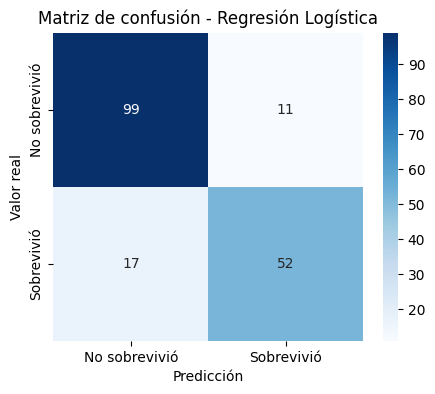

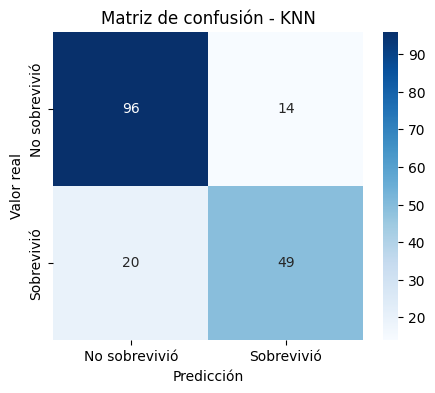

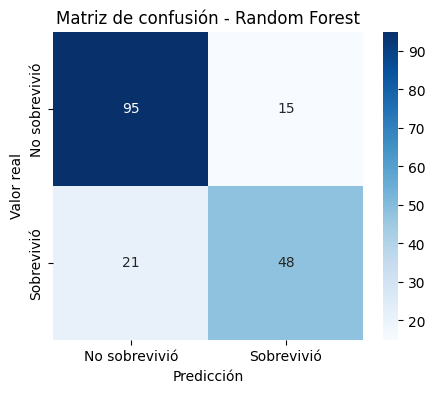

In [151]:
for nombre, modelo in modelos.items():

    y_pred = modelo.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No sobrevivió', 'Sobrevivió'],
        yticklabels=['No sobrevivió', 'Sobrevivió']
    )

    plt.title(f'Matriz de confusión - {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Valor real')

    plt.show()

**Análisis de Errores (Matrices de Confusión):**

En este problema, un Falso Negativo significa clasificar como "Muerto" a alguien que realmente sobrevivió, mientras que un Falso Positivo significa clasificar como "Sobreviviente" a alguien que realmente falleció.

**Al comparar los modelos:**

La Regresión Logística presentó menos Falsos Negativos (17 casos), lo que indica que logró identificar una mayor cantidad de sobrevivientes reales.
El Random Forest presentó 21 Falsos Negativos, mostrando un mayor número de errores en la identificación de la clase positiva.

Esta diferencia, junto con el mayor Recall de la Regresión Logística, indica que este modelo tuvo un mejor desempeño en la identificación de los casos positivos dentro de este conjunto de datos.

>**40. Curvas ROC**

---

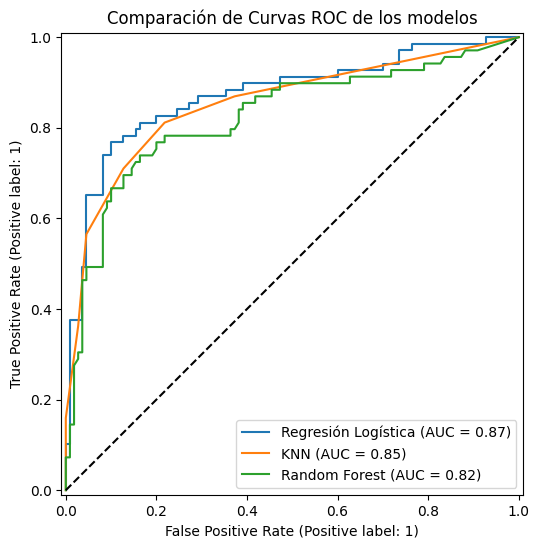

In [152]:
fig, ax = plt.subplots(figsize=(8, 6))
for nombre, modelo in modelos.items():
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, name=nombre, ax=ax)
plt.title("Comparación de Curvas ROC de los modelos")
plt.plot([0, 1], [0, 1], 'k--', label='Azar')
plt.show()

>**41. Selección del Modelo y Conclusiones Finales**

**Selección del Modelo Óptimo:**

Con base en los resultados obtenidos en el conjunto de prueba, se selecciona la **Regresión Logística como modelo final**. Esta decisión se fundamenta principalmente en los siguientes aspectos:

1. **Rendimiento General:** Obtuvo el F1-score más alto (0.7879) y el mayor Accuracy global, lo que indica un mejor desempeño en los datos de prueba.

2. **Análisis de Errores:** Presentó la menor cantidad de Falsos Negativos en la matriz de confusión, identificando una mayor cantidad de sobrevivientes reales frente a KNN y Random Forest.

3. **Simplicidad y Explicabilidad:** Al ser el modelo menos complejo de los tres, permite una interpretación más sencilla de la relación entre las variables y la probabilidad de supervivencia. Además, sus coeficientes permiten analizar el efecto de cada variable dentro del modelo.


**Conclusiones del Proyecto:**


---



* El preprocesamiento mediante `Pipelines` y `ColumnTransformer` fue fundamental para evitar el *data leakage* y aplicar las transformaciones correspondientes, como la imputación de la edad mediante la mediana y de las variables categóricas mediante la moda.

* La ingeniería de características tuvo un impacto importante en el rendimiento del modelo. Extraer el Título del pasajero y agrupar variables como la tarifa y la edad permitió que la Regresión Logística representara mejor la relación entre las características y la supervivencia.

* El ejercicio demuestra que, en problemas con datos estructurados y de baja dimensionalidad, un modelo más complejo como Random Forest no necesariamente obtiene mejores resultados que un modelo estadístico más sencillo cuando los datos han sido correctamente limpiados, transformados y preparados.

**Anexo**


---

Enlace de acceso: https://colab.research.google.com/drive/11riN28-hbGkiN47iKdGwjTd7InoF3D7c?usp=sharing

